In [1]:
import os
import numpy as np
import pywt
import time
import cv2
from pathlib import Path
from scipy.fft import fft2, fftshift
from scipy.fft import dctn
from skimage.feature import local_binary_pattern

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix, roc_curve)
import matplotlib.pyplot as plt

In [2]:
#Notebook variables definition
DATA_ROOT   = Path("dataset")

SPLITS = {
    "train": {"real": DATA_ROOT / "train" / "real", "fake": DATA_ROOT / "train" / "fake"},
    "valid": {"real": DATA_ROOT / "valid" / "real", "fake": DATA_ROOT / "valid" / "fake"},
    "test":  {"real": DATA_ROOT / "test"  / "real", "fake": DATA_ROOT / "test"  / "fake"},
}

FEATURES_DIR = Path("features_stage1")
FEATURES_DIR.mkdir(exist_ok=True)

CHECKPOINT_DIR = Path("checkpoints_stage1")
CHECKPOINT_DIR.mkdir(exist_ok=True)


IMAGE_SIZE = (128, 128)

#For feature extraction
LBP_POINTS   = 8
LBP_RADIUS   = 2
LBP_BINS     = 59          # nri_uniform with P=8, 59 uniform patterns

FFT_BINS     = 64          # number of radial frequency bins

DCT_BLOCK    = 8           # top-left (DCT_BLOCK * DCT_BLOCK) coefficients kept

WAVELET      = "db1"
WAVELET_LEVEL = 2          # subbands: 3*level + 1, 7 subbands × 2 stats = 14 features

#For training
BATCH_SIZE   = 256
LR           = 1e-3
EPOCHS       = 30
DROPOUT      = 0.4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
#Feature extraction functions

def extract_lbp(gray):
    """LBP histogram, 59 bins (nri_uniform, P=8, R=2)."""
    lbp = local_binary_pattern(gray, P=LBP_POINTS, R=LBP_RADIUS, method='nri_uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, LBP_BINS + 1), density=True)
    return hist.astype(np.float32)


def extract_fft(gray):
    """Radial average of log-magnitude FFT spectrum, FT_BINS values."""
    mag = np.abs(fftshift(fft2(gray.astype(np.float32))))
    log_mag = np.log1p(mag)

    h, w = log_mag.shape
    cy, cx = h // 2, w // 2
    radii = np.hypot(*np.indices((h, w)) - np.array([cy, cx])[:, None, None]).ravel()

    max_r = min(cy, cx)
    bin_idx = np.clip((radii / max_r * FFT_BINS).astype(int), 0, FFT_BINS - 1)

    flat = log_mag.ravel()
    counts = np.bincount(bin_idx, minlength=FFT_BINS)
    sums   = np.bincount(bin_idx, weights=flat, minlength=FFT_BINS)
    spectrum = np.where(counts > 0, sums / counts, 0).astype(np.float32)
    return spectrum


def extract_dct(gray):
    """Top-left DCT_BLOCK×DCT_BLOCK DCT coefficients, flattened."""
    coeffs = dctn(gray.astype(np.float32), norm='ortho')
    return coeffs[:DCT_BLOCK, :DCT_BLOCK].flatten().astype(np.float32)


def extract_wavelet(gray):
    """Mean + std of every subband from a WAVELET_LEVEL 2D DWT."""
    coeffs = pywt.wavedec2(gray.astype(np.float32), wavelet=WAVELET, level=WAVELET_LEVEL)
    feats = [coeffs[0].mean(), coeffs[0].std()]
    for detail_tuple in coeffs[1:]:
        for subband in detail_tuple:
            feats.extend([subband.mean(), subband.std()])
    return np.array(feats, dtype=np.float32)


def load_and_resize_gray(img_path):
    """Load image, resize, return (bgr, gray). Returns None on failure."""
    img = cv2.imread(str(img_path))
    if img is None:
        return None, None
    img = cv2.resize(img, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img, gray

In [4]:
#Extracting and saving features

def extract_features_from_folder(folder_path):
    """Extract all four features for every image in a folder."""
    lbp_list, fft_list, dct_list, wav_list, names = [], [], [], [], []

    img_files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    for filename in img_files:
        _, gray = load_and_resize_gray(Path(folder_path) / filename)
        if gray is None:
            print(f"  [WARN] Could not read {filename}, skipping.")
            continue
        lbp_list.append(extract_lbp(gray))
        fft_list.append(extract_fft(gray))
        dct_list.append(extract_dct(gray))
        wav_list.append(extract_wavelet(gray))
        names.append(filename)

    return {
        'lbp':      np.array(lbp_list),
        'fft':      np.array(fft_list),
        'dct':      np.array(dct_list),
        'wavelet':  np.array(wav_list),
        'filenames': np.array(names)
    }


for split, classes in SPLITS.items():
    for cls, folder in classes.items():
        out_path = FEATURES_DIR / f"{split}_{cls}_features.npz"

        if out_path.exists():
            print(f"[SKIP] {out_path.name}")
            continue

        print(f"\n[EXTRACTING] {split}/{cls}  ({folder})")
        t0 = time.time()
        data = extract_features_from_folder(folder)
        elapsed = time.time() - t0

        np.savez_compressed(out_path, **data)
        n = len(data['filenames'])
        print(f"  {n} images | {elapsed:.1f}s | saved → {out_path.name}")

print("\n Feature dimensions")
sample = np.load(FEATURES_DIR / "train_real_features.npz")
total  = 0
for key in ['lbp', 'fft', 'dct', 'wavelet']:
    d = sample[key].shape[1]
    total += d
    print(f"  {key:<10} {d:>4} features")
print(f"  {'TOTAL':<10} {total:>4} features")

[SKIP] train_real_features.npz
[SKIP] train_fake_features.npz
[SKIP] valid_real_features.npz
[SKIP] valid_fake_features.npz
[SKIP] test_real_features.npz
[SKIP] test_fake_features.npz

 Feature dimensions
  lbp          59 features
  fft          64 features
  dct          64 features
  wavelet      14 features
  TOTAL       201 features


In [5]:
#Load features before standardizing
import joblib

FEATURE_KEYS = ['lbp', 'fft', 'dct', 'wavelet']
SCALER_PATH  = FEATURES_DIR / "scaler.joblib"


def load_split_features(split_name):
    """Load, concatenate, and label real+fake features for one split."""
    real_data = np.load(FEATURES_DIR / f"{split_name}_real_features.npz")
    fake_data = np.load(FEATURES_DIR / f"{split_name}_fake_features.npz")

    X_real = np.concatenate([real_data[k] for k in FEATURE_KEYS], axis=1)
    X_fake = np.concatenate([fake_data[k] for k in FEATURE_KEYS], axis=1)

    X = np.vstack([X_real, X_fake]).astype(np.float32)
    y = np.hstack([
        np.ones(len(X_real),  dtype=np.float32),   # real = 1
        np.zeros(len(X_fake), dtype=np.float32)    # fake = 0
    ])
    return X, y


X_train_raw, y_train = load_split_features('train')
X_valid_raw, y_valid = load_split_features('valid')
X_test_raw,  y_test  = load_split_features('test')

In [6]:

class FeatureDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


#Fitting/loading scaler
if SCALER_PATH.exists():
    print(f"[SKIP] Loading scaler from {SCALER_PATH.name}")
    scaler = joblib.load(SCALER_PATH)
else:
    print("Fitting StandardScaler on training features")
    scaler = StandardScaler()
    scaler.fit(X_train_raw)
    joblib.dump(scaler, SCALER_PATH)
    print(f"Scaler saved: {SCALER_PATH.name}")

#Fit on train
X_train = scaler.transform(X_train_raw).astype(np.float32)
X_valid = scaler.transform(X_valid_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)


train_dataset = FeatureDataset(X_train, y_train)
valid_dataset = FeatureDataset(X_valid, y_valid)
test_dataset  = FeatureDataset(X_test,  y_test)

#num_workers=0 avoids multiprocessing issues
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


input_dim = X_train.shape[1]
print(f"\n Dataset summary")
print(f"  Feature vector dim : {input_dim}")
for name, ds, y in [("Train", train_dataset, y_train),
                    ("Valid", valid_dataset, y_valid),
                    ("Test",  test_dataset,  y_test)]:
    print(f"  {name:<6}: {len(ds):>6} samples  "
          f"(real={int(y.sum())}, fake={int((y == 0).sum())})")

[SKIP] Loading scaler from scaler.joblib

 Dataset summary
  Feature vector dim : 201
  Train :  30000 samples  (real=15000, fake=15000)
  Valid :   5000 samples  (real=2500, fake=2500)
  Test  :   5000 samples  (real=2500, fake=2500)


In [7]:
#MLP build
class FCNet(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: tuple = (512, 128), dropout: float = DROPOUT):
        super().__init__()

        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers += [
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, 1))  #single logit output
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(1) 


model = FCNet(input_dim=input_dim).to(DEVICE)

print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

FCNet(
  (net): Sequential(
    (0): Linear(in_features=201, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)

Trainable parameters: 170,497


In [8]:
#Setup and training functions
CHECKPOINT_PATH = CHECKPOINT_DIR / "fc_best.pt"

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(y_batch)
        correct += ((torch.sigmoid(logits) >= 0.5).float() == y_batch).sum().item()
        total   += len(y_batch)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        running_loss += loss.item() * len(y_batch)
        correct += ((torch.sigmoid(logits) >= 0.5).float() == y_batch).sum().item()
        total   += len(y_batch)
    return running_loss / total, correct / total

In [9]:
#Training loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')

if CHECKPOINT_PATH.exists():
    print(f"[SKIP] Checkpoint found — loading {CHECKPOINT_PATH.name}")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    history       = ckpt['history']
    best_val_loss = ckpt['best_val_loss']
    print(f"  Best val loss: {best_val_loss:.4f}  (epoch {ckpt['epoch'] + 1})")

else:
    print(f"Training for {EPOCHS} epochs \n")
    for epoch in range(EPOCHS):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_acc   = evaluate(model, valid_loader, criterion)
        elapsed = time.time() - t0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        tag = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss':        best_val_loss,
                'epoch':                epoch,
                'history':              history,
            }, CHECKPOINT_PATH)
            tag = ' saved'

        print(f"Epoch {epoch+1:02d}/{EPOCHS}"
              f"\ntrain loss {train_loss:.4f}  acc {train_acc:.4f}"
              f"\nval loss {val_loss:.4f}  acc {val_acc:.4f}"
              f"\n{elapsed:.1f}s{tag}")

    print(f"\nBest val loss: {best_val_loss:.4f}")

#Restore best weights before evaluation
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print("\nBest weights loaded")

[SKIP] Checkpoint found — loading fc_best.pt
  Best val loss: 0.4108  (epoch 19)

Best weights loaded


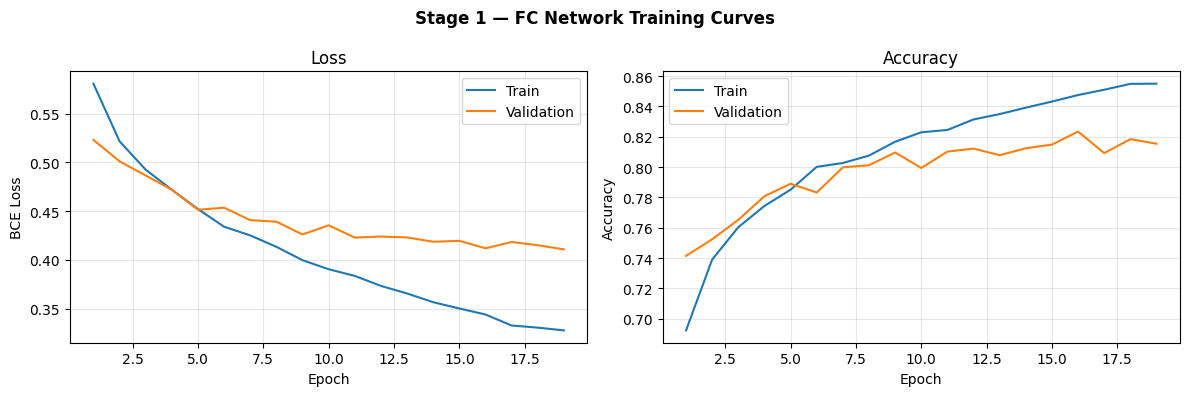

In [10]:
#Training curves plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_x, history['train_loss'], label='Train')
ax1.plot(epochs_x, history['val_loss'],   label='Validation')
ax1.set(title='Loss', xlabel='Epoch', ylabel='BCE Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_x, history['train_acc'], label='Train')
ax2.plot(epochs_x, history['val_acc'],   label='Validation')
ax2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Stage 1 — FC Network Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
#Inference helper
@torch.no_grad()
def get_predictions(model, loader):
    """Run inference over a loader, returns (y_true, y_pred, y_prob) as numpy arrays."""
    model.eval()
    all_labels, all_probs = [], []
    for X_batch, y_batch in loader:
        probs = torch.sigmoid(model(X_batch.to(DEVICE))).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())
    y_true = np.array(all_labels)
    y_prob = np.array(all_probs)
    y_pred = (y_prob >= 0.5).astype(int)
    return y_true, y_pred, y_prob


def compute_metrics(y_true, y_pred, y_prob, dataset_name):
    """Compute, print, and return the full metric suite."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    cm   = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n {dataset_name}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"                  Pred Fake  Pred Real")
    print(f"Actual Fake :   {tn:6d}     {fp:6d}")
    print(f"Actual Real :   {fn:6d}     {tp:6d}")
    print(f"\nTN {tn} : correctly identified as Fake")
    print(f"FP {fp} : Fake images wrongly called Real")
    print(f"FN {fn} : Real images wrongly called Fake")
    print(f"TP {tp} : correctly identified as Real")

    return dict(acc=acc, prec=prec, rec=rec, f1=f1, auc=auc, cm=cm)

In [12]:
#Evaluating on validation set
y_true_val, y_pred_val, y_prob_val = get_predictions(model, valid_loader)
metrics_val = compute_metrics(y_true_val, y_pred_val, y_prob_val, "Validation")


 Validation
Accuracy  : 0.8154
Precision : 0.8214
Recall    : 0.8060
F1        : 0.8136
ROC-AUC   : 0.8964

  Confusion Matrix:
                  Pred Fake  Pred Real
Actual Fake :     2062        438
Actual Real :      485       2015

TN 2062 : correctly identified as Fake
FP 438 : Fake images wrongly called Real
FN 485 : Real images wrongly called Fake
TP 2015 : correctly identified as Real


In [13]:
tn, fp, fn, tp = confusion_matrix(y_true_val, y_pred_val).ravel()
print(f"Sample check: of {tn+fp} actual Fake images, {tn} were correctly called Fake")
print(f"Sample check: of {tp+fn} actual Real images, {tp} were correctly called Real")

Sample check: of 2500 actual Fake images, 2062 were correctly called Fake
Sample check: of 2500 actual Real images, 2015 were correctly called Real


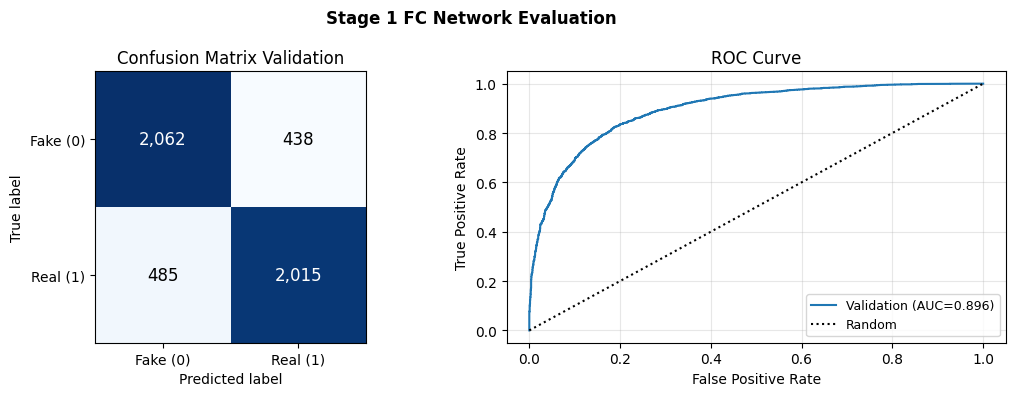

In [14]:
#Confusion Matrix & ROC Curve
def plot_cm(ax, cm, title):
    ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set(title=title, ylabel='True label', xlabel='Predicted label')
    labels = ['Fake (0)', 'Real (1)']
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black', fontsize=12)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

plot_cm(ax1, metrics_val['cm'], 'Confusion Matrix Validation')

fpr, tpr, _ = roc_curve(y_true_val, y_prob_val)
ax2.plot(fpr, tpr, label=f"Validation (AUC={metrics_val['auc']:.3f})")
ax2.plot([0, 1], [0, 1], 'k:', label='Random')
ax2.set(title='ROC Curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle('Stage 1 FC Network Evaluation', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
#Import and Configs for Deep Learning
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image

IMG_SIZE_S2        = 128
CNN_BATCH_SIZE     = 64
CNN_EPOCHS         = 30
CNN_LR             = 0.01
CNN_DROPOUT        = 0.5

CHECKPOINT_DIR_S2  = Path("checkpoints_stage2")
CHECKPOINT_DIR_S2.mkdir(exist_ok=True)

NORM_STATS_PATH    = CHECKPOINT_DIR_S2 / "norm_stats.pt"

print(f"Initial config")
print(f"Image size : {IMG_SIZE_S2}×{IMG_SIZE_S2}")
print(f"Batch size : {CNN_BATCH_SIZE}")
print(f"Epochs     : {CNN_EPOCHS}")
print(f"LR         : {CNN_LR}")
print(f"Device     : {DEVICE}")

Initial config
Image size : 128×128
Batch size : 64
Epochs     : 30
LR         : 0.01
Device     : cuda


In [16]:
#Image dataset
class DeepfakeImageDataset(Dataset):
    def __init__(self, real_dir: Path, fake_dir: Path, transform=None):
        self.transform = transform
        self.samples   = []

        for path in sorted(Path(real_dir).iterdir()):
            if path.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                self.samples.append((path, 1.0))   # real = 1

        for path in sorted(Path(fake_dir).iterdir()):
            if path.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                self.samples.append((path, 0.0))   # fake = 0

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

In [17]:
#Normalization stats
if NORM_STATS_PATH.exists():
    print(f"[SKIP] Loading norm stats from {NORM_STATS_PATH.name}")
    stats      = torch.load(NORM_STATS_PATH)
    norm_mean  = stats['mean']
    norm_std   = stats['std']
else:
    print("Computing per-channel mean and std over training set")
    _pre_transform = T.Compose([T.Resize((IMG_SIZE_S2, IMG_SIZE_S2)), T.ToTensor()])
    _stat_dataset  = DeepfakeImageDataset(
        SPLITS['train']['real'], SPLITS['train']['fake'], transform=_pre_transform
    )
    _stat_loader = DataLoader(_stat_dataset, batch_size=256, shuffle=False, num_workers=0)

    pixel_sum    = torch.zeros(3)
    pixel_sq_sum = torch.zeros(3)
    n_pixels     = 0

    for images, _ in _stat_loader:
        pixel_sum    += images.sum(dim=[0, 2, 3])
        pixel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])
        n_pixels     += images.shape[0] * images.shape[2] * images.shape[3]

    norm_mean = pixel_sum / n_pixels
    norm_std  = (pixel_sq_sum / n_pixels - norm_mean ** 2).sqrt()

    torch.save({'mean': norm_mean, 'std': norm_std}, NORM_STATS_PATH)
    print(f"Saved → {NORM_STATS_PATH.name}")

print(f"mean : {[round(v, 2) for v in norm_mean.tolist()]}")
print(f"std  : {[round(v, 2) for v in norm_std.tolist()]}")


[SKIP] Loading norm stats from norm_stats.pt
mean : [0.52, 0.43, 0.38]
std  : [0.28, 0.25, 0.25]


In [18]:
#Transforms
base_transform = T.Compose([
    T.Resize((IMG_SIZE_S2, IMG_SIZE_S2)),
    T.ToTensor(),
    T.Normalize(mean=norm_mean.tolist(), std=norm_std.tolist()),
])


#Datasets and dataloaders
train_dataset_s2 = DeepfakeImageDataset(
    SPLITS['train']['real'], SPLITS['train']['fake'], transform=base_transform
)
valid_dataset_s2 = DeepfakeImageDataset(
    SPLITS['valid']['real'], SPLITS['valid']['fake'], transform=base_transform
)

train_loader_s2 = DataLoader(
    train_dataset_s2, batch_size=CNN_BATCH_SIZE, shuffle=True,  num_workers=0
)
valid_loader_s2 = DataLoader(
    valid_dataset_s2, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"\nDataset summary")
print(f"Train : {len(train_dataset_s2):>6} images")
print(f"Valid : {len(valid_dataset_s2):>6} images")
print(f"Batch size : {CNN_BATCH_SIZE}"
      f"\nTrain batches: {len(train_loader_s2)}"
      f"\nValid batches: {len(valid_loader_s2)}")


Dataset summary
Train :  30000 images
Valid :   5000 images
Batch size : 64
Train batches: 469
Valid batches: 79


In [19]:
#3-block CNN with flatten head, establishes whether raw pixels + spatial learning beats
#hand-crafted features.

class CNNA(nn.Module):
    def __init__(self, dropout: float = CNN_DROPOUT):
        super().__init__()

        self.features = nn.Sequential(
            #Block 1: 128×128 to 64×64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            #Block 2: 64x64 to 32×32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            #Block 3: 32×32 to 16×16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x)).squeeze(1)


model_cnn_a = CNNA().to(DEVICE)
print(model_cnn_a)
n_params = sum(p.numel() for p in model_cnn_a.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

CNNA(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features

In [20]:
#CNN-A training setup
CKPT_CNN_A = CHECKPOINT_DIR_S2 / "cnn_a_best.pt"

optimizer_cnn_a = torch.optim.Adam(model_cnn_a.parameters(), lr=CNN_LR)

history_cnn_a = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss  = float('inf')

if CKPT_CNN_A.exists():
    print(f"[SKIP] Checkpoint found — loading {CKPT_CNN_A.name}")
    ckpt          = torch.load(CKPT_CNN_A, map_location=DEVICE)
    model_cnn_a.load_state_dict(ckpt['model_state_dict'])
    history_cnn_a = ckpt['history']
    best_val_loss  = ckpt['best_val_loss']
    print(f"  Best val loss: {best_val_loss:.4f}  (epoch {ckpt['epoch'] + 1})")

else:
    print(f"Training CNN-A for {CNN_EPOCHS} epochs\n")
    for epoch in range(CNN_EPOCHS):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model_cnn_a, train_loader_s2, criterion, optimizer_cnn_a)
        val_loss,   val_acc   = evaluate(model_cnn_a, valid_loader_s2, criterion)
        elapsed = time.time() - t0

        history_cnn_a['train_loss'].append(train_loss)
        history_cnn_a['val_loss'].append(val_loss)
        history_cnn_a['train_acc'].append(train_acc)
        history_cnn_a['val_acc'].append(val_acc)

        tag = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict':     model_cnn_a.state_dict(),
                'optimizer_state_dict': optimizer_cnn_a.state_dict(),
                'best_val_loss':        best_val_loss,
                'epoch':                epoch,
                'history':              history_cnn_a,
            }, CKPT_CNN_A)
            tag = '  saved'

        print(f"Epoch {epoch+1:02d}/{CNN_EPOCHS}"
              f"\ntrain loss {train_loss:.4f}  acc {train_acc:.4f}"
              f"\nval loss {val_loss:.4f}  acc {val_acc:.4f}"
              f"{elapsed:.1f}s{tag}")

    print(f"\nBest val loss: {best_val_loss:.4f}")

# Always restore best weights
ckpt = torch.load(CKPT_CNN_A, map_location=DEVICE)
model_cnn_a.load_state_dict(ckpt['model_state_dict'])
print("Best weights loaded.")

[SKIP] Checkpoint found — loading cnn_a_best.pt
  Best val loss: 0.1353  (epoch 28)
Best weights loaded.


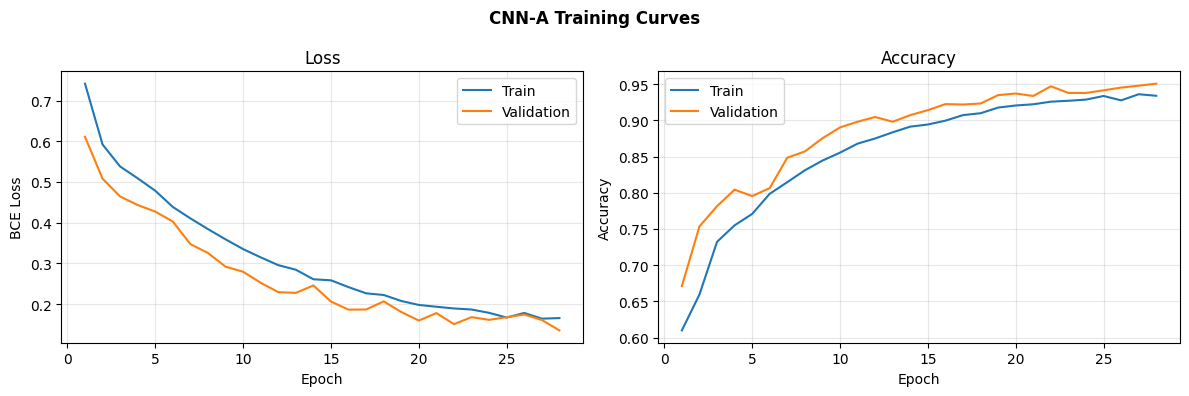

In [21]:
#CNN-A training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, len(history_cnn_a['train_loss']) + 1)

ax1.plot(epochs_x, history_cnn_a['train_loss'], label='Train')
ax1.plot(epochs_x, history_cnn_a['val_loss'],   label='Validation')
ax1.set(title='Loss', xlabel='Epoch', ylabel='BCE Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_x, history_cnn_a['train_acc'], label='Train')
ax2.plot(epochs_x, history_cnn_a['val_acc'],   label='Validation')
ax2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CNN-A Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR_S2 / 'cnn_a_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


 CNN-A Validation
Accuracy  : 0.9506
Precision : 0.9519
Recall    : 0.9492
F1        : 0.9505
ROC-AUC   : 0.9897

  Confusion Matrix:
                  Pred Fake  Pred Real
Actual Fake :     2380        120
Actual Real :      127       2373

TN 2380 : correctly identified as Fake
FP 120 : Fake images wrongly called Real
FN 127 : Real images wrongly called Fake
TP 2373 : correctly identified as Real


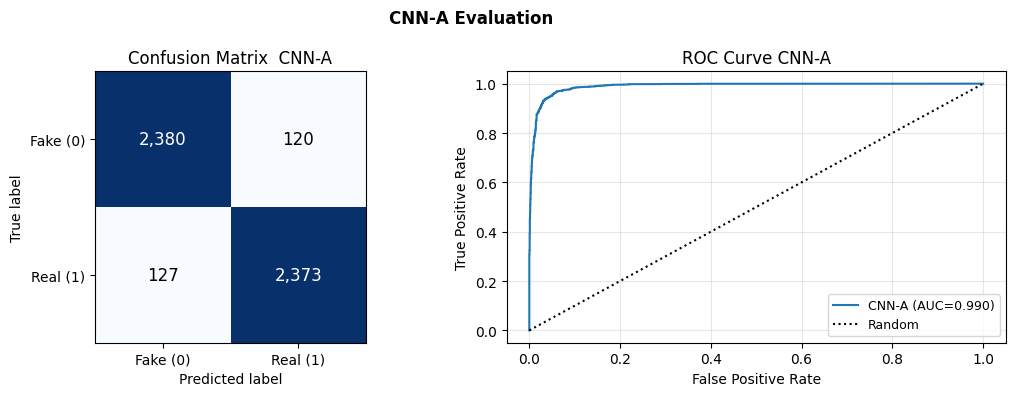

In [22]:
#CNN-A validation evaluation
y_true_cnn_a, y_pred_cnn_a, y_prob_cnn_a = get_predictions(model_cnn_a, valid_loader_s2)
metrics_cnn_a = compute_metrics(y_true_cnn_a, y_pred_cnn_a, y_prob_cnn_a, "CNN-A Validation")

#Confusion matrix & Roc Curve plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

plot_cm(ax1, metrics_cnn_a['cm'], 'Confusion Matrix  CNN-A')

fpr, tpr, _ = roc_curve(y_true_cnn_a, y_prob_cnn_a)
ax2.plot(fpr, tpr, label=f"CNN-A (AUC={metrics_cnn_a['auc']:.3f})")
ax2.plot([0, 1], [0, 1], 'k:', label='Random')
ax2.set(title='ROC Curve CNN-A', xlabel='False Positive Rate',
        ylabel='True Positive Rate')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle('CNN-A Evaluation', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR_S2 / 'cnn_a_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
#4-block CNN with Global Average Pooling head
class CNNB(nn.Module):

    def __init__(self, dropout: float = CNN_DROPOUT):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 128×128 to 64×64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: 64×64 to 32×32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: 32×32 to 16×16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4: 16×16 to 8×8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x)).squeeze(1)


model_cnn_b = CNNB().to(DEVICE)
print(model_cnn_b)
n_params = sum(p.numel() for p in model_cnn_b.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

CNNB(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=Tru

In [24]:
#CNN-B training setup
CKPT_CNN_B = CHECKPOINT_DIR_S2 / "cnn_b_best.pt"

optimizer_cnn_b = torch.optim.Adam(model_cnn_b.parameters(), lr=CNN_LR)

history_cnn_b = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss  = float('inf')

if CKPT_CNN_B.exists():
    print(f"[SKIP] Checkpoint found, loading {CKPT_CNN_B.name}")
    ckpt          = torch.load(CKPT_CNN_B, map_location=DEVICE)
    model_cnn_b.load_state_dict(ckpt['model_state_dict'])
    history_cnn_b = ckpt['history']
    best_val_loss  = ckpt['best_val_loss']
    print(f"  Best val loss: {best_val_loss:.4f}  (epoch {ckpt['epoch'] + 1})")

else:
    print(f"Training CNN-B for {CNN_EPOCHS} epochs\n")
    for epoch in range(CNN_EPOCHS):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model_cnn_b, train_loader_s2, criterion, optimizer_cnn_b)
        val_loss,   val_acc   = evaluate(model_cnn_b, valid_loader_s2, criterion)
        elapsed = time.time() - t0

        history_cnn_b['train_loss'].append(train_loss)
        history_cnn_b['val_loss'].append(val_loss)
        history_cnn_b['train_acc'].append(train_acc)
        history_cnn_b['val_acc'].append(val_acc)

        tag = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict':     model_cnn_b.state_dict(),
                'optimizer_state_dict': optimizer_cnn_b.state_dict(),
                'best_val_loss':        best_val_loss,
                'epoch':                epoch,
                'history':              history_cnn_b,
            }, CKPT_CNN_B)
            tag = '  saved'

        print(f"Epoch {epoch+1:02d}/{CNN_EPOCHS}"
              f"\ntrain loss {train_loss:.4f}  acc {train_acc:.4f}"
              f"\nval loss {val_loss:.4f}  acc {val_acc:.4f}"
              f"\n{elapsed:.1f}s{tag}")

    print(f"\nBest val loss: {best_val_loss:.4f}")

ckpt = torch.load(CKPT_CNN_B, map_location=DEVICE)
model_cnn_b.load_state_dict(ckpt['model_state_dict'])
print("Best weights loaded.")

[SKIP] Checkpoint found, loading cnn_b_best.pt
  Best val loss: 0.1079  (epoch 29)
Best weights loaded.


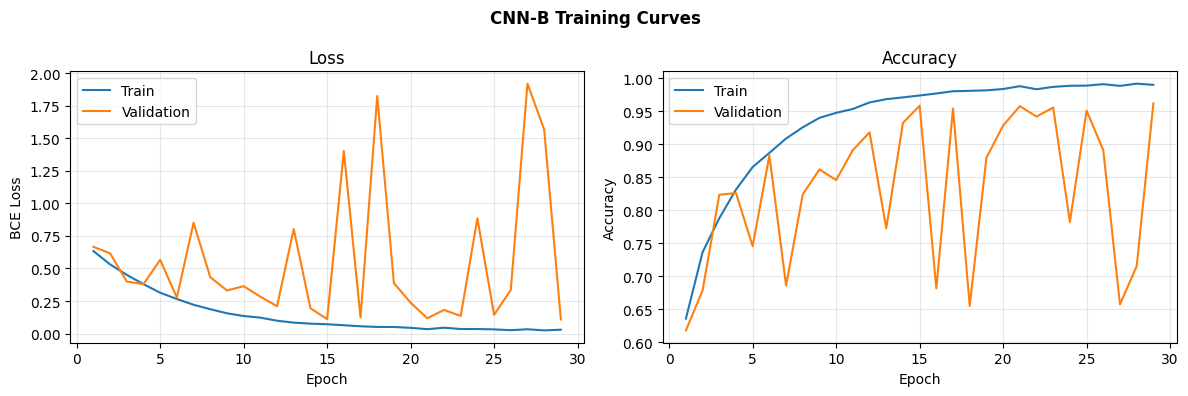

In [25]:
#CNN-B training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, len(history_cnn_b['train_loss']) + 1)

ax1.plot(epochs_x, history_cnn_b['train_loss'], label='Train')
ax1.plot(epochs_x, history_cnn_b['val_loss'],   label='Validation')
ax1.set(title='Loss', xlabel='Epoch', ylabel='BCE Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_x, history_cnn_b['train_acc'], label='Train')
ax2.plot(epochs_x, history_cnn_b['val_acc'],   label='Validation')
ax2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CNN-B Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR_S2 / 'cnn_b_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


 CNN-B Validation
Accuracy  : 0.9618
Precision : 0.9672
Recall    : 0.9560
F1        : 0.9616
ROC-AUC   : 0.9939

  Confusion Matrix:
                  Pred Fake  Pred Real
Actual Fake :     2419         81
Actual Real :      110       2390

TN 2419 : correctly identified as Fake
FP 81 : Fake images wrongly called Real
FN 110 : Real images wrongly called Fake
TP 2390 : correctly identified as Real


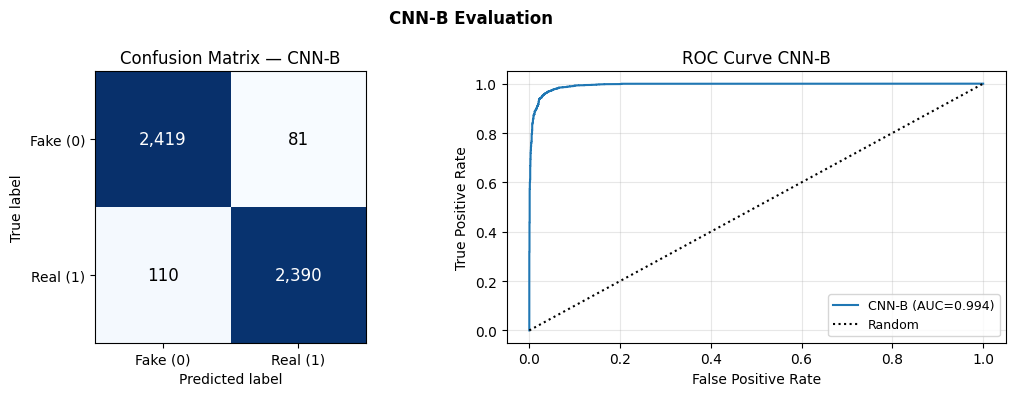

In [26]:
#CNN-B validation evaluation
y_true_cnn_b, y_pred_cnn_b, y_prob_cnn_b = get_predictions(model_cnn_b, valid_loader_s2)
metrics_cnn_b = compute_metrics(y_true_cnn_b, y_pred_cnn_b, y_prob_cnn_b, "CNN-B Validation")

#Confusion matrix & Roc Curve plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

plot_cm(ax1, metrics_cnn_b['cm'], 'Confusion Matrix — CNN-B')

fpr, tpr, _ = roc_curve(y_true_cnn_b, y_prob_cnn_b)
ax2.plot(fpr, tpr, label=f"CNN-B (AUC={metrics_cnn_b['auc']:.3f})")
ax2.plot([0, 1], [0, 1], 'k:', label='Random')
ax2.set(title='ROC Curve CNN-B', xlabel='False Positive Rate',
        ylabel='True Positive Rate')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle('CNN-B Evaluation', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR_S2 / 'cnn_b_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
#CNN-C augmented training transform
aug_transform = T.Compose([
    T.Resize((IMG_SIZE_S2, IMG_SIZE_S2)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.RandomRotation(degrees=10),
    T.ToTensor(),
    T.Normalize(mean=norm_mean.tolist(), std=norm_std.tolist()),
])

train_dataset_cnn_c = DeepfakeImageDataset(
    SPLITS['train']['real'], SPLITS['train']['fake'], transform=aug_transform
)
train_loader_cnn_c = DataLoader(
    train_dataset_cnn_c, batch_size=CNN_BATCH_SIZE, shuffle=True, num_workers=0
)

# Validation loader is shared, augmentation is never applied to val
print(f"CNN-C train loader : {len(train_loader_cnn_c)} batches  (augmented)")
print(f"CNN-C valid loader : {len(valid_loader_s2)} batches  (base transform, shared)")
print(f"\nAugmentation pipeline:")
for t in aug_transform.transforms:
    print(f"  {t}")

print(f"\n  mean: {[round(m, 2) for m in norm_mean.tolist()]}")
print(f"  std:  {[round(s, 2) for s in norm_std.tolist()]}\n")


CNN-C train loader : 469 batches  (augmented)
CNN-C valid loader : 79 batches  (base transform, shared)

Augmentation pipeline:
  Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
  RandomHorizontalFlip(p=0.5)
  ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=(-0.05, 0.05))
  RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
  ToTensor()
  Normalize(mean=[0.5216386914253235, 0.42695072293281555, 0.3818354308605194], std=[0.27524471282958984, 0.25004488229751587, 0.25106167793273926])

  mean: [0.52, 0.43, 0.38]
  std:  [0.28, 0.25, 0.25]



In [28]:
#This is identical to CNN-B
model_cnn_c = CNNB().to(DEVICE)
print(model_cnn_c)
n_params = sum(p.numel() for p in model_cnn_c.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

CNNB(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=Tru

In [29]:
#CNN-C training setup
CKPT_CNN_C = CHECKPOINT_DIR_S2 / "cnn_c_best.pt"

optimizer_cnn_c = torch.optim.Adam(model_cnn_c.parameters(), lr=CNN_LR)

history_cnn_c = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss  = float('inf')

if CKPT_CNN_C.exists():
    print(f"[SKIP] Checkpoint found, loading {CKPT_CNN_C.name}")
    ckpt          = torch.load(CKPT_CNN_C, map_location=DEVICE)
    model_cnn_c.load_state_dict(ckpt['model_state_dict'])
    history_cnn_c = ckpt['history']
    best_val_loss  = ckpt['best_val_loss']
    print(f"  Best val loss: {best_val_loss:.4f}  (epoch {ckpt['epoch'] + 1})")

else:
    print(f"Training CNN-C for {CNN_EPOCHS} epochs\n")
    for epoch in range(CNN_EPOCHS):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model_cnn_c, train_loader_cnn_c, criterion, optimizer_cnn_c)
        val_loss,   val_acc   = evaluate(model_cnn_c, valid_loader_s2, criterion)
        elapsed = time.time() - t0

        history_cnn_c['train_loss'].append(train_loss)
        history_cnn_c['val_loss'].append(val_loss)
        history_cnn_c['train_acc'].append(train_acc)
        history_cnn_c['val_acc'].append(val_acc)

        tag = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict':     model_cnn_c.state_dict(),
                'optimizer_state_dict': optimizer_cnn_c.state_dict(),
                'best_val_loss':        best_val_loss,
                'epoch':                epoch,
                'history':              history_cnn_c,
            }, CKPT_CNN_C)
            tag = '  saved'

        print(f"Epoch {epoch+1:02d}/{CNN_EPOCHS}"
              f"\ntrain loss {train_loss:.4f}  acc {train_acc:.4f}"
              f"\nval loss {val_loss:.4f}  acc {val_acc:.4f}"
              f"\n{elapsed:.1f}s{tag}")

    print(f"\nBest val loss: {best_val_loss:.4f}")

ckpt = torch.load(CKPT_CNN_C, map_location=DEVICE)
model_cnn_c.load_state_dict(ckpt['model_state_dict'])
print("Best weights loaded.")

[SKIP] Checkpoint found, loading cnn_c_best.pt
  Best val loss: 0.1585  (epoch 28)
Best weights loaded.


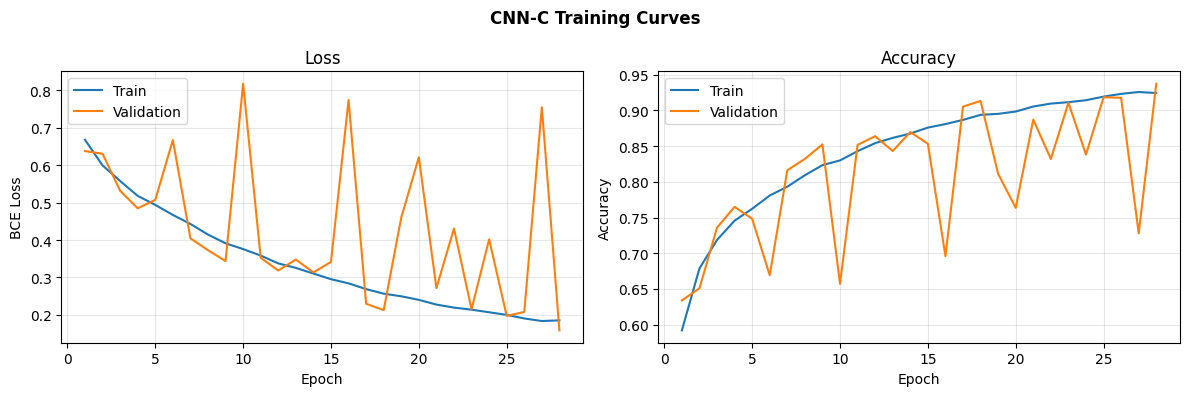

In [30]:
#CNN-C training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, len(history_cnn_c['train_loss']) + 1)

ax1.plot(epochs_x, history_cnn_c['train_loss'], label='Train')
ax1.plot(epochs_x, history_cnn_c['val_loss'],   label='Validation')
ax1.set(title='Loss', xlabel='Epoch', ylabel='BCE Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_x, history_cnn_c['train_acc'], label='Train')
ax2.plot(epochs_x, history_cnn_c['val_acc'],   label='Validation')
ax2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CNN-C Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR_S2 / 'cnn_c_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


 CNN-C Validation
Accuracy  : 0.9376
Precision : 0.9359
Recall    : 0.9396
F1        : 0.9377
ROC-AUC   : 0.9844

  Confusion Matrix:
                  Pred Fake  Pred Real
Actual Fake :     2339        161
Actual Real :      151       2349

TN 2339 : correctly identified as Fake
FP 161 : Fake images wrongly called Real
FN 151 : Real images wrongly called Fake
TP 2349 : correctly identified as Real


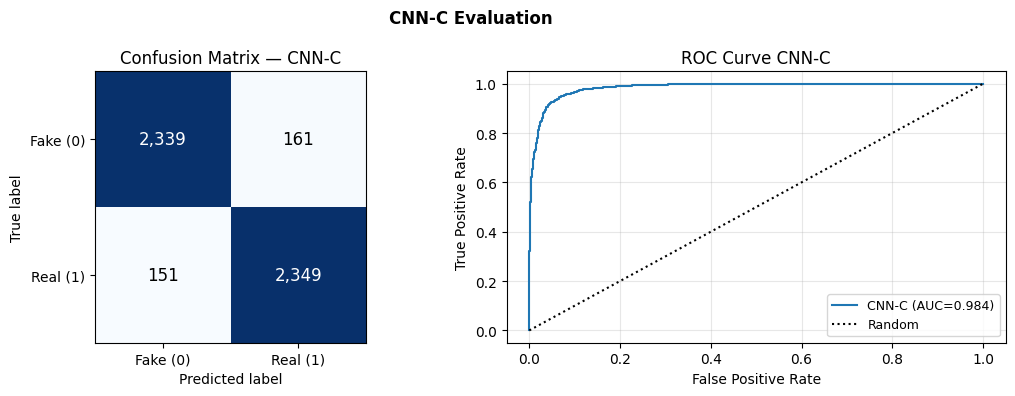

In [31]:
#CNN-C validation evaluation
y_true_cnn_c, y_pred_cnn_c, y_prob_cnn_c = get_predictions(model_cnn_c, valid_loader_s2)
metrics_cnn_c = compute_metrics(y_true_cnn_c, y_pred_cnn_c, y_prob_cnn_c, "CNN-C Validation")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

plot_cm(ax1, metrics_cnn_c['cm'], 'Confusion Matrix — CNN-C')

fpr, tpr, _ = roc_curve(y_true_cnn_c, y_prob_cnn_c)
ax2.plot(fpr, tpr, label=f"CNN-C (AUC={metrics_cnn_c['auc']:.3f})")
ax2.plot([0, 1], [0, 1], 'k:', label='Random')
ax2.set(title='ROC Curve CNN-C', xlabel='False Positive Rate',
        ylabel='True Positive Rate')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle('CNN-C Evaluation', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR_S2 / 'cnn_c_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
#Pretrained models import and config
import torchvision.models as models

IMG_SIZE_S3        = 224
PT_BATCH_SIZE      = 32
PT_EPOCHS          = 20
PT_LR              = 0.0001

PT_SCHED_PATIENCE  = 3      #epochs of no val loss improvement before LR reduction
PT_SCHED_FACTOR    = 0.5    #multiplicative LR reduction factor

# ImageNet normalisation constants (must match the pretrained backbone's training distribution)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CHECKPOINT_DIR_S3 = Path("checkpoints_stage3")
CHECKPOINT_DIR_S3.mkdir(exist_ok=True)

print("PT config")
print(f"Image size : {IMG_SIZE_S3}×{IMG_SIZE_S3}")
print(f"Batch size : {PT_BATCH_SIZE}")
print(f"Epochs     : {PT_EPOCHS}")
print(f"LR         : {PT_LR}")
print(f"Scheduler  : ReduceLROnPlateau  "
      f"(patience={PT_SCHED_PATIENCE}, factor={PT_SCHED_FACTOR})")
print(f"Device     : {DEVICE}")

PT config
Image size : 224×224
Batch size : 32
Epochs     : 20
LR         : 0.0001
Scheduler  : ReduceLROnPlateau  (patience=3, factor=0.5)
Device     : cuda


In [33]:
#PT transforms
train_transform_s3 = T.Compose([
    T.Resize((IMG_SIZE_S3, IMG_SIZE_S3)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform_s3 = T.Compose([
    T.Resize((IMG_SIZE_S3, IMG_SIZE_S3)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [34]:
#Datasets and loaders
train_dataset_s3 = DeepfakeImageDataset(
    SPLITS['train']['real'], SPLITS['train']['fake'], transform=train_transform_s3
)
valid_dataset_s3 = DeepfakeImageDataset(
    SPLITS['valid']['real'], SPLITS['valid']['fake'], transform=val_transform_s3
)

train_loader_s3 = DataLoader(
    train_dataset_s3, batch_size=PT_BATCH_SIZE, shuffle=True,  num_workers=0
)
valid_loader_s3 = DataLoader(
    valid_dataset_s3, batch_size=PT_BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"dataset summary")
print(f"Train : {len(train_dataset_s3):>6} images,  {len(train_loader_s3)} batches")
print(f"Valid : {len(valid_dataset_s3):>6} images,  {len(valid_loader_s3)} batches")
print(f"\nTrain transform : {train_transform_s3}")
print(f"\nVal transform   : {val_transform_s3}")

dataset summary
Train :  30000 images,  938 batches
Valid :   5000 images,  157 batches

Train transform : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.95, 1.05), hue=(-0.02, 0.02))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val transform   : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [35]:
#Pretrained ResNet-18 with the final FC replaced for binary classification
class ResNet18Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        backbone    = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Linear(backbone.fc.in_features, 1)
        self.model  = backbone

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x).squeeze(1)


model_resnet = ResNet18Classifier().to(DEVICE)

print(f"Backbone    : ResNet-18 (pretrained ImageNet)")
print(f"Output head : {model_resnet.model.fc}")

n_total     = sum(p.numel() for p in model_resnet.parameters())
n_trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {n_total:,}")
print(f"Trainable parameters : {n_trainable:,}")

Backbone    : ResNet-18 (pretrained ImageNet)
Output head : Linear(in_features=512, out_features=1, bias=True)

Total parameters     : 11,177,025
Trainable parameters : 11,177,025


In [36]:
#ResNet-18 training setup
CKPT_RESNET = CHECKPOINT_DIR_S3 / "resnet18_best.pt"

optimizer_resnet = torch.optim.Adam(model_resnet.parameters(), lr=PT_LR)
scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet, mode='min', patience=PT_SCHED_PATIENCE, factor=PT_SCHED_FACTOR
)

history_resnet = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss  = float('inf')

if CKPT_RESNET.exists():
    print(f"[SKIP] Checkpoint found, loading {CKPT_RESNET.name}")
    ckpt          = torch.load(CKPT_RESNET, map_location=DEVICE)
    model_resnet.load_state_dict(ckpt['model_state_dict'])
    history_resnet = ckpt['history']
    best_val_loss  = ckpt['best_val_loss']
    print(f"  Best val loss: {best_val_loss:.4f}  (epoch {ckpt['epoch'] + 1})")

else:
    print(f"Training ResNet-18 for {PT_EPOCHS} epochs\n")
    for epoch in range(PT_EPOCHS):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model_resnet, train_loader_s3, criterion, optimizer_resnet)
        val_loss,   val_acc   = evaluate(model_resnet, valid_loader_s3, criterion)
        current_lr = optimizer_resnet.param_groups[0]['lr']
        scheduler_resnet.step(val_loss)
        elapsed = time.time() - t0

        history_resnet['train_loss'].append(train_loss)
        history_resnet['val_loss'].append(val_loss)
        history_resnet['train_acc'].append(train_acc)
        history_resnet['val_acc'].append(val_acc)

        tag = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict':     model_resnet.state_dict(),
                'optimizer_state_dict': optimizer_resnet.state_dict(),
                'scheduler_state_dict': scheduler_resnet.state_dict(),
                'best_val_loss':        best_val_loss,
                'epoch':                epoch,
                'history':             history_resnet,
            }, CKPT_RESNET)
            tag = '  saved'

        print(f"\nEpoch {epoch+1:02d}/{PT_EPOCHS}"
              f"\ntrain loss {train_loss:.4f}  acc {train_acc:.4f}"
              f"\nval loss {val_loss:.4f}  acc {val_acc:.4f}"
              f"\nlr {current_lr:.1e}, {elapsed:.1f}s{tag}")

    print(f"\nBest val loss: {best_val_loss:.4f}")

ckpt = torch.load(CKPT_RESNET, map_location=DEVICE)
model_resnet.load_state_dict(ckpt['model_state_dict'])
print("Best weights loaded.")

[SKIP] Checkpoint found, loading resnet18_best.pt
  Best val loss: 0.1528  (epoch 6)
Best weights loaded.


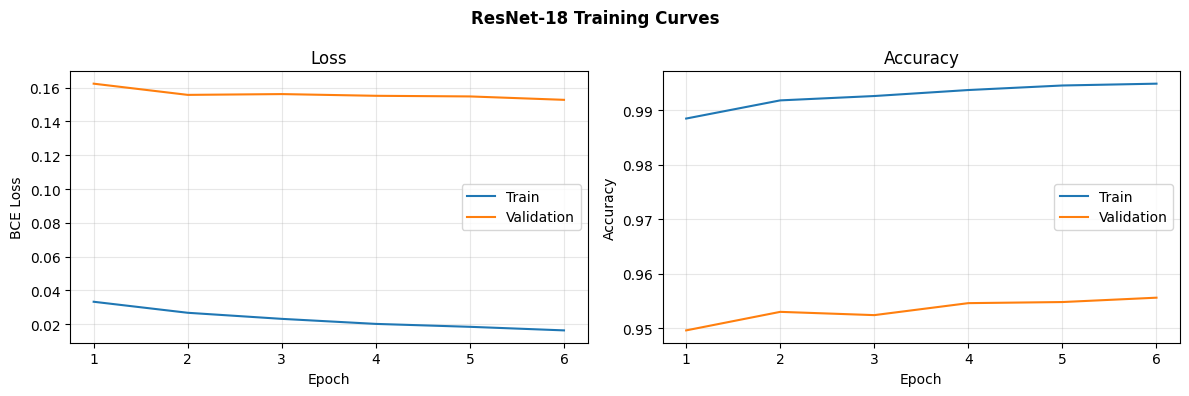

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, len(history_resnet['train_loss']) + 1)

ax1.plot(epochs_x, history_resnet['train_loss'], label='Train')
ax1.plot(epochs_x, history_resnet['val_loss'],   label='Validation')
ax1.set(title='Loss', xlabel='Epoch', ylabel='BCE Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_x, history_resnet['train_acc'], label='Train')
ax2.plot(epochs_x, history_resnet['val_acc'],   label='Validation')
ax2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('ResNet-18 Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR_S3 / 'resnet18_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


 ResNet-18 Validation
Accuracy  : 0.9556
Precision : 0.9560
Recall    : 0.9552
F1        : 0.9556
ROC-AUC   : 0.9895

  Confusion Matrix:
                  Pred Fake  Pred Real
Actual Fake :     2390        110
Actual Real :      112       2388

TN 2390 : correctly identified as Fake
FP 110 : Fake images wrongly called Real
FN 112 : Real images wrongly called Fake
TP 2388 : correctly identified as Real


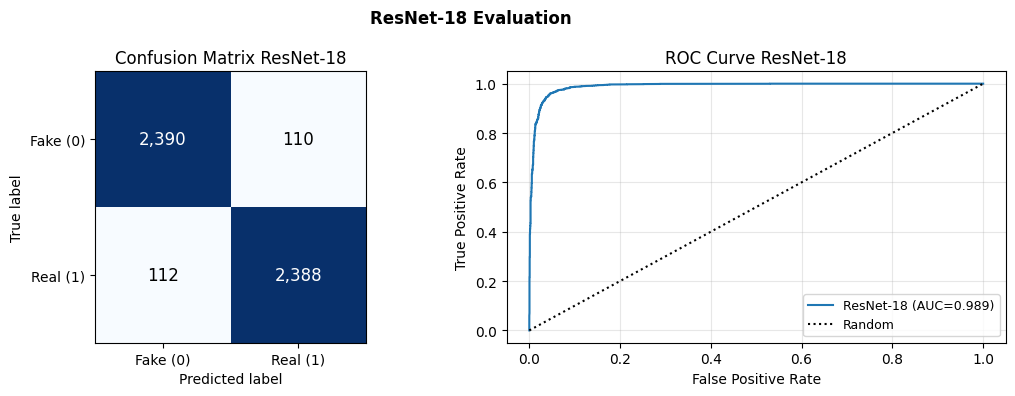

In [38]:
#ResNet-18 validation evaluation
y_true_resnet, y_pred_resnet, y_prob_resnet = get_predictions(model_resnet, valid_loader_s3)
metrics_resnet = compute_metrics(y_true_resnet, y_pred_resnet, y_prob_resnet, "ResNet-18 Validation")

#ResNet-18 plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

plot_cm(ax1, metrics_resnet['cm'], 'Confusion Matrix ResNet-18')

fpr, tpr, _ = roc_curve(y_true_resnet, y_prob_resnet)
ax2.plot(fpr, tpr, label=f"ResNet-18 (AUC={metrics_resnet['auc']:.3f})")
ax2.plot([0, 1], [0, 1], 'k:', label='Random')
ax2.set(title='ROC Curve ResNet-18', xlabel='False Positive Rate',
        ylabel='True Positive Rate')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle('ResNet-18 Evaluation', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR_S3 / 'resnet18_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
#Pretrained EfficientNet-B0 with the classifier head replaced for binary output.
class EfficientNetB0Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        backbone        = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features     = backbone.classifier[1].in_features
        backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.2, inplace=True),
            nn.Linear(in_features, 1),
        )
        self.model = backbone

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x).squeeze(1)


model_effnet = EfficientNetB0Classifier().to(DEVICE)

print(f"Backbone    : EfficientNet-B0 (pretrained ImageNet)")
print(f"Output head : {model_effnet.model.classifier}")

n_total     = sum(p.numel() for p in model_effnet.parameters())
n_trainable = sum(p.numel() for p in model_effnet.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {n_total:,}")
print(f"Trainable parameters : {n_trainable:,}")

Backbone    : EfficientNet-B0 (pretrained ImageNet)
Output head : Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)

Total parameters     : 4,008,829
Trainable parameters : 4,008,829


In [40]:
#EfficientNet-B0 training setup
CKPT_EFFNET = CHECKPOINT_DIR_S3 / "efficientnet_b0_best.pt"

optimizer_effnet = torch.optim.Adam(model_effnet.parameters(), lr=PT_LR)
scheduler_effnet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_effnet, mode='min', patience=PT_SCHED_PATIENCE, factor=PT_SCHED_FACTOR
)

history_effnet = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss  = float('inf')

if CKPT_EFFNET.exists():
    print(f"[SKIP] Checkpoint found, loading {CKPT_EFFNET.name}")
    ckpt           = torch.load(CKPT_EFFNET, map_location=DEVICE)
    model_effnet.load_state_dict(ckpt['model_state_dict'])
    history_effnet = ckpt['history']
    best_val_loss  = ckpt['best_val_loss']
    print(f"  Best val loss: {best_val_loss:.4f}  (epoch {ckpt['epoch'] + 1})")

else:
    print(f"Training EfficientNet-B0 for {PT_EPOCHS} epochs\n")
    for epoch in range(PT_EPOCHS):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model_effnet, train_loader_s3, criterion, optimizer_effnet)
        val_loss,   val_acc   = evaluate(model_effnet, valid_loader_s3, criterion)
        current_lr = optimizer_effnet.param_groups[0]['lr']
        scheduler_effnet.step(val_loss)
        elapsed = time.time() - t0

        history_effnet['train_loss'].append(train_loss)
        history_effnet['val_loss'].append(val_loss)
        history_effnet['train_acc'].append(train_acc)
        history_effnet['val_acc'].append(val_acc)

        tag = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict':     model_effnet.state_dict(),
                'optimizer_state_dict': optimizer_effnet.state_dict(),
                'scheduler_state_dict': scheduler_effnet.state_dict(),
                'best_val_loss':        best_val_loss,
                'epoch':                epoch,
                'history':             history_effnet,
            }, CKPT_EFFNET)
            tag = '  saved'

        print(f"\nEpoch {epoch+1:02d}/{PT_EPOCHS}"
              f"\ntrain loss {train_loss:.4f}  acc {train_acc:.4f}"
              f"\nval loss {val_loss:.4f}  acc {val_acc:.4f}"
              f"\nlr {current_lr:.1e}, {elapsed:.1f}s{tag}")

    print(f"\nBest val loss: {best_val_loss:.4f}")

# Always restore best weights
ckpt = torch.load(CKPT_EFFNET, map_location=DEVICE)
model_effnet.load_state_dict(ckpt['model_state_dict'])
print("Best weights loaded.")

[SKIP] Checkpoint found, loading efficientnet_b0_best.pt
  Best val loss: 0.0828  (epoch 19)
Best weights loaded.


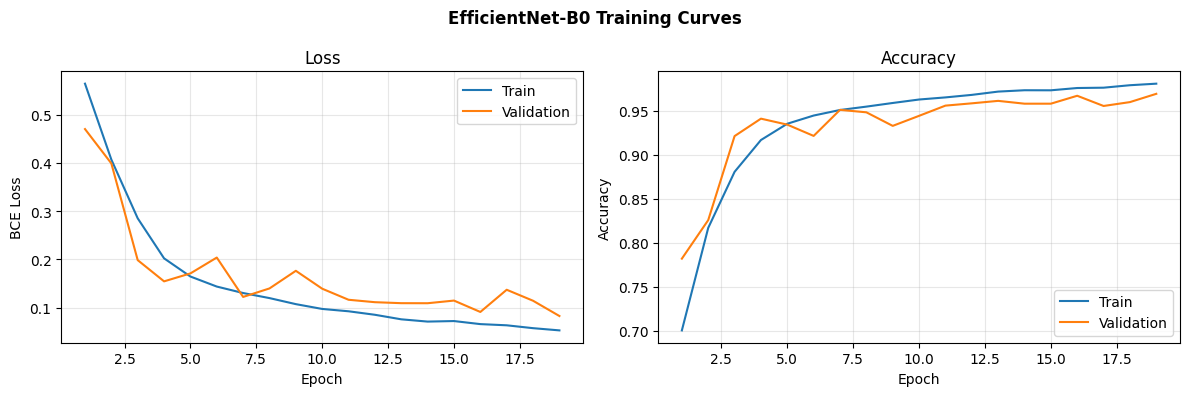

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, len(history_effnet['train_loss']) + 1)

ax1.plot(epochs_x, history_effnet['train_loss'], label='Train')
ax1.plot(epochs_x, history_effnet['val_loss'],   label='Validation')
ax1.set(title='Loss', xlabel='Epoch', ylabel='BCE Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_x, history_effnet['train_acc'], label='Train')
ax2.plot(epochs_x, history_effnet['val_acc'],   label='Validation')
ax2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('EfficientNet-B0 Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR_S3 / 'efficientnet_b0_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


 EfficientNet-B0 Validation
Accuracy  : 0.9690
Precision : 0.9718
Recall    : 0.9660
F1        : 0.9689
ROC-AUC   : 0.9958

  Confusion Matrix:
                  Pred Fake  Pred Real
Actual Fake :     2430         70
Actual Real :       85       2415

TN 2430 : correctly identified as Fake
FP 70 : Fake images wrongly called Real
FN 85 : Real images wrongly called Fake
TP 2415 : correctly identified as Real


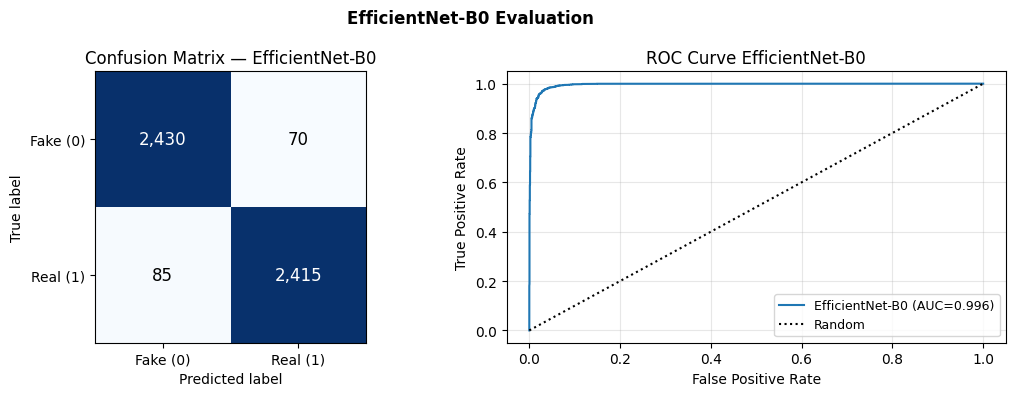

In [42]:
#EfficientNet-B0 validation evaluation
y_true_effnet, y_pred_effnet, y_prob_effnet = get_predictions(model_effnet, valid_loader_s3)
metrics_effnet = compute_metrics(y_true_effnet, y_pred_effnet, y_prob_effnet, "EfficientNet-B0 Validation")

#EfficientNet-B0 plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

plot_cm(ax1, metrics_effnet['cm'], 'Confusion Matrix — EfficientNet-B0')

fpr, tpr, _ = roc_curve(y_true_effnet, y_prob_effnet)
ax2.plot(fpr, tpr, label=f"EfficientNet-B0 (AUC={metrics_effnet['auc']:.3f})")
ax2.plot([0, 1], [0, 1], 'k:', label='Random')
ax2.set(title='ROC Curve EfficientNet-B0', xlabel='False Positive Rate',
        ylabel='True Positive Rate')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle('EfficientNet-B0 Evaluation', fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR_S3 / 'efficientnet_b0_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
#Test DataLoaders
#Stage 1 test_loader already exists in memory (feature vectors)

test_dataset_s2 = DeepfakeImageDataset(
    SPLITS['test']['real'], SPLITS['test']['fake'], transform=base_transform
)
test_loader_s2 = DataLoader(
    test_dataset_s2, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=0
)

test_dataset_s3 = DeepfakeImageDataset(
    SPLITS['test']['real'], SPLITS['test']['fake'], transform=val_transform_s3
)
test_loader_s3 = DataLoader(
    test_dataset_s3, batch_size=PT_BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Test DataLoaders:")
print(f"FullyConnected, features (201-dim)    : {len(test_loader):>4} batches")
print(f"CNNs, images  (128×128)               : {len(test_loader_s2):>4} batches")
print(f"Pretrained models, images  (224×224)  : {len(test_loader_s3):>4} batches")

Test DataLoaders:
FullyConnected, features (201-dim)    :   20 batches
CNNs, images  (128×128)               :   79 batches
Pretrained models, images  (224×224)  :  157 batches


In [44]:
#Run inference on all models
print("FINAL HOLDOUT TEST EVALUATION")
print("Test set was not used at any point during development.\n")

all_models = [
    ("FC Baseline",     model,        test_loader),
    ("CNN-A",           model_cnn_a,  test_loader_s2),
    ("CNN-B",           model_cnn_b,  test_loader_s2),
    ("CNN-C",           model_cnn_c,  test_loader_s2),
    ("ResNet-18",       model_resnet, test_loader_s3),
    ("EfficientNet-B0", model_effnet, test_loader_s3),
]

test_results = {}
for name, mdl, loader in all_models:
    y_true, y_pred, y_prob = get_predictions(mdl, loader)
    metrics = compute_metrics(y_true, y_pred, y_prob, f"{name} — Test")
    test_results[name] = {'metrics': metrics, 'y_true': y_true, 'y_prob': y_prob}

FINAL HOLDOUT TEST EVALUATION
Test set was not used at any point during development.


 FC Baseline — Test
Accuracy  : 0.8164
Precision : 0.8195
Recall    : 0.8116
F1        : 0.8155
ROC-AUC   : 0.8945

  Confusion Matrix:
                  Pred Fake  Pred Real
Actual Fake :     2053        447
Actual Real :      471       2029

TN 2053 : correctly identified as Fake
FP 447 : Fake images wrongly called Real
FN 471 : Real images wrongly called Fake
TP 2029 : correctly identified as Real

 CNN-A — Test
Accuracy  : 0.9498
Precision : 0.9536
Recall    : 0.9456
F1        : 0.9496
ROC-AUC   : 0.9898

  Confusion Matrix:
                  Pred Fake  Pred Real
Actual Fake :     2385        115
Actual Real :      136       2364

TN 2385 : correctly identified as Fake
FP 115 : Fake images wrongly called Real
FN 136 : Real images wrongly called Fake
TP 2364 : correctly identified as Real

 CNN-B — Test
Accuracy  : 0.9594
Precision : 0.9611
Recall    : 0.9576
F1        : 0.9593
ROC-AUC   : 0.9921


In [45]:
#Summary table
print(" FINAL TEST SET RESULTS — ALL MODELS")
print(f"  {'Model':<20} {'Accuracy':>9} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")
for name, data in test_results.items():
    m = data['metrics']
    print(f"  {name:<20} {m['acc']:>9.4f} {m['prec']:>10.4f} "
          f"{m['rec']:>8.4f} {m['f1']:>8.4f} {m['auc']:>9.4f}")

 FINAL TEST SET RESULTS — ALL MODELS
  Model                 Accuracy  Precision   Recall       F1   ROC-AUC
  FC Baseline             0.8164     0.8195   0.8116   0.8155    0.8945
  CNN-A                   0.9498     0.9536   0.9456   0.9496    0.9898
  CNN-B                   0.9594     0.9611   0.9576   0.9593    0.9921
  CNN-C                   0.9314     0.9278   0.9356   0.9317    0.9826
  ResNet-18               0.9524     0.9539   0.9508   0.9523    0.9891
  EfficientNet-B0         0.9722     0.9793   0.9648   0.9720    0.9969


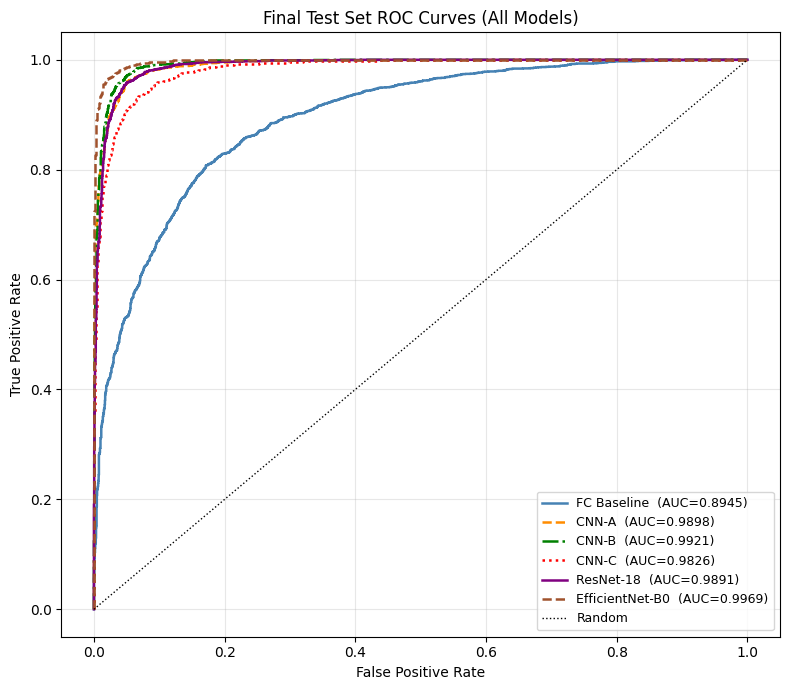

In [46]:
#Combined ROC curves
fig, ax = plt.subplots(figsize=(8, 7))

styles = [
    ('steelblue',   '-'),
    ('darkorange',  '--'),
    ('green',       '-.'),
    ('red',         ':'),
    ('purple',      '-'),
    ('sienna',      '--'),
]

for (name, data), (color, ls) in zip(test_results.items(), styles):
    fpr, tpr, _ = roc_curve(data['y_true'], data['y_prob'])
    ax.plot(fpr, tpr, color=color, ls=ls, lw=1.8,
            label=f"{name}  (AUC={data['metrics']['auc']:.4f})")

ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Random')
ax.set(title='Final Test Set ROC Curves (All Models)',
       xlabel='False Positive Rate', ylabel='True Positive Rate')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR_S3 / 'final_roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
#Cross dataset config
SD_ROOT          = Path("")
SD_DIRS          = [SD_ROOT / "man", SD_ROOT / "woman"]
SD_FEATURES_PATH = FEATURES_DIR / "cross_sd_features.npz"


class AllFakeDataset(Dataset):
    """Image dataset where every sample has label 0 (fake). Accepts multiple source dirs."""
    def __init__(self, dirs, transform=None):
        self.transform = transform
        self.samples   = []
        for d in dirs:
            for path in sorted(Path(d).iterdir()):
                if path.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                    self.samples.append(path)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image = Image.open(self.samples[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(0.0, dtype=torch.float32)


#Feature extraction
if SD_FEATURES_PATH.exists():
    print(f"[SKIP] Loading SD features from {SD_FEATURES_PATH.name}")
    sd_data = np.load(SD_FEATURES_PATH)
else:
    print("Extracting features from Stable Diffusion dataset")
    lbp_all, fft_all, dct_all, wav_all, names_all = [], [], [], [], []

    for d in SD_DIRS:
        print(f"  Processing {d.name}/")
        data = extract_features_from_folder(d)
        lbp_all.append(data['lbp'])
        fft_all.append(data['fft'])
        dct_all.append(data['dct'])
        wav_all.append(data['wavelet'])
        names_all.append(data['filenames'])

    sd_data = {
        'lbp':       np.vstack(lbp_all),
        'fft':       np.vstack(fft_all),
        'dct':       np.vstack(dct_all),
        'wavelet':   np.vstack(wav_all),
        'filenames': np.concatenate(names_all),
    }
    np.savez_compressed(SD_FEATURES_PATH, **sd_data)
    print(f"  {len(sd_data['filenames'])} images, saved to {SD_FEATURES_PATH.name}")

[SKIP] Loading SD features from cross_sd_features.npz


In [48]:
#Dataloaders

#feature vectors, scaled
X_sd        = np.concatenate([sd_data[k] for k in FEATURE_KEYS], axis=1).astype(np.float32)
X_sd_scaled = scaler.transform(X_sd).astype(np.float32)
y_sd        = np.zeros(len(X_sd), dtype=np.float32)

sd_feature_dataset = FeatureDataset(X_sd_scaled, y_sd)
sd_feature_loader  = DataLoader(
    sd_feature_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

#128×128, dataset normalisation
sd_image_dataset_s2 = AllFakeDataset(SD_DIRS, transform=base_transform)
sd_image_loader_s2  = DataLoader(
    sd_image_dataset_s2, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=0
)

#224×224, ImageNet normalisation
sd_image_dataset_s3 = AllFakeDataset(SD_DIRS, transform=val_transform_s3)
sd_image_loader_s3  = DataLoader(
    sd_image_dataset_s3, batch_size=PT_BATCH_SIZE, shuffle=False, num_workers=0
)

#Summary
n_total = len(sd_feature_dataset)
print(f"Cross-dataset summary")
print(f"  Total SD images    : {n_total}")
print(f"  All labels         : 0 (fake)")
print(f"  Stage 1 loader     : {len(sd_feature_loader)} batches  (feature vectors)")
print(f"  Stage 2 loader     : {len(sd_image_loader_s2)} batches  (128×128)")
print(f"  Stage 3 loader     : {len(sd_image_loader_s3)} batches  (224×224)")

Cross-dataset summary
  Total SD images    : 3000
  All labels         : 0 (fake)
  Stage 1 loader     : 12 batches  (feature vectors)
  Stage 2 loader     : 47 batches  (128×128)
  Stage 3 loader     : 94 batches  (224×224)


In [49]:
#Cross-dataset evaluation helper
def evaluate_all_fake(name, y_pred, y_prob):
    total          = len(y_pred)
    n_correct      = int((y_pred == 0).sum())
    n_missed       = total - n_correct
    detection_rate = n_correct / total
    print(f"\n{name}")
    print(f"  Total SD images      : {total}")
    print(f"  Correctly (fake)     : {n_correct:>5}  ({detection_rate*100:.1f}%)")
    print(f"  Wrongly   (real)     : {n_missed:>5}  ({(1-detection_rate)*100:.1f}%)")

    return detection_rate, n_correct, n_missed


#Run inference
cross_models = [
    ("FC Baseline",     model,        sd_feature_loader),
    ("CNN-A",           model_cnn_a,  sd_image_loader_s2),
    ("CNN-B",           model_cnn_b,  sd_image_loader_s2),
    ("CNN-C",           model_cnn_c,  sd_image_loader_s2),
    ("ResNet-18",       model_resnet, sd_image_loader_s3),
    ("EfficientNet-B0", model_effnet, sd_image_loader_s3),
]

cross_results = {}
print("CROSS-DISTRIBUTION GENERALISATION STABLE DIFFUSION")

for name, mdl, loader in cross_models:
    _, y_pred, y_prob = get_predictions(mdl, loader)
    det_rate, n_correct, n_missed = evaluate_all_fake(name, y_pred, y_prob)
    cross_results[name] = {
        'detection_rate': det_rate,
        'n_correct':      n_correct,
        'n_missed':       n_missed,
        'y_prob':         y_prob,
    }

CROSS-DISTRIBUTION GENERALISATION STABLE DIFFUSION

FC Baseline
  Total SD images      : 3000
  Correctly (fake)     :    25  (0.8%)
  Wrongly   (real)     :  2975  (99.2%)

CNN-A
  Total SD images      : 3000
  Correctly (fake)     :     3  (0.1%)
  Wrongly   (real)     :  2997  (99.9%)

CNN-B
  Total SD images      : 3000
  Correctly (fake)     :    40  (1.3%)
  Wrongly   (real)     :  2960  (98.7%)

CNN-C
  Total SD images      : 3000
  Correctly (fake)     :    50  (1.7%)
  Wrongly   (real)     :  2950  (98.3%)

ResNet-18
  Total SD images      : 3000
  Correctly (fake)     :     2  (0.1%)
  Wrongly   (real)     :  2998  (99.9%)

EfficientNet-B0
  Total SD images      : 3000
  Correctly (fake)     :    54  (1.8%)
  Wrongly   (real)     :  2946  (98.2%)


In [50]:
#Summary table
total = len(next(iter(cross_results.values()))['y_prob'])

print(" CROSS-DATASET DETECTION SUMMARY (all GT = fake)")
print(f"  {'Model':<20} {'Detected Fake':>14} {'Missed (Real)':>15}")
for name, data in cross_results.items():
    print(f"  {name:<20} "
          f"{data['n_correct']:>5} / {total}  ({data['detection_rate']*100:5.1f}%)  "
          f"{data['n_missed']:>5}  ({(1-data['detection_rate'])*100:4.1f}%)")


 CROSS-DATASET DETECTION SUMMARY (all GT = fake)
  Model                 Detected Fake   Missed (Real)
  FC Baseline             25 / 3000  (  0.8%)   2975  (99.2%)
  CNN-A                    3 / 3000  (  0.1%)   2997  (99.9%)
  CNN-B                   40 / 3000  (  1.3%)   2960  (98.7%)
  CNN-C                   50 / 3000  (  1.7%)   2950  (98.3%)
  ResNet-18                2 / 3000  (  0.1%)   2998  (99.9%)
  EfficientNet-B0         54 / 3000  (  1.8%)   2946  (98.2%)


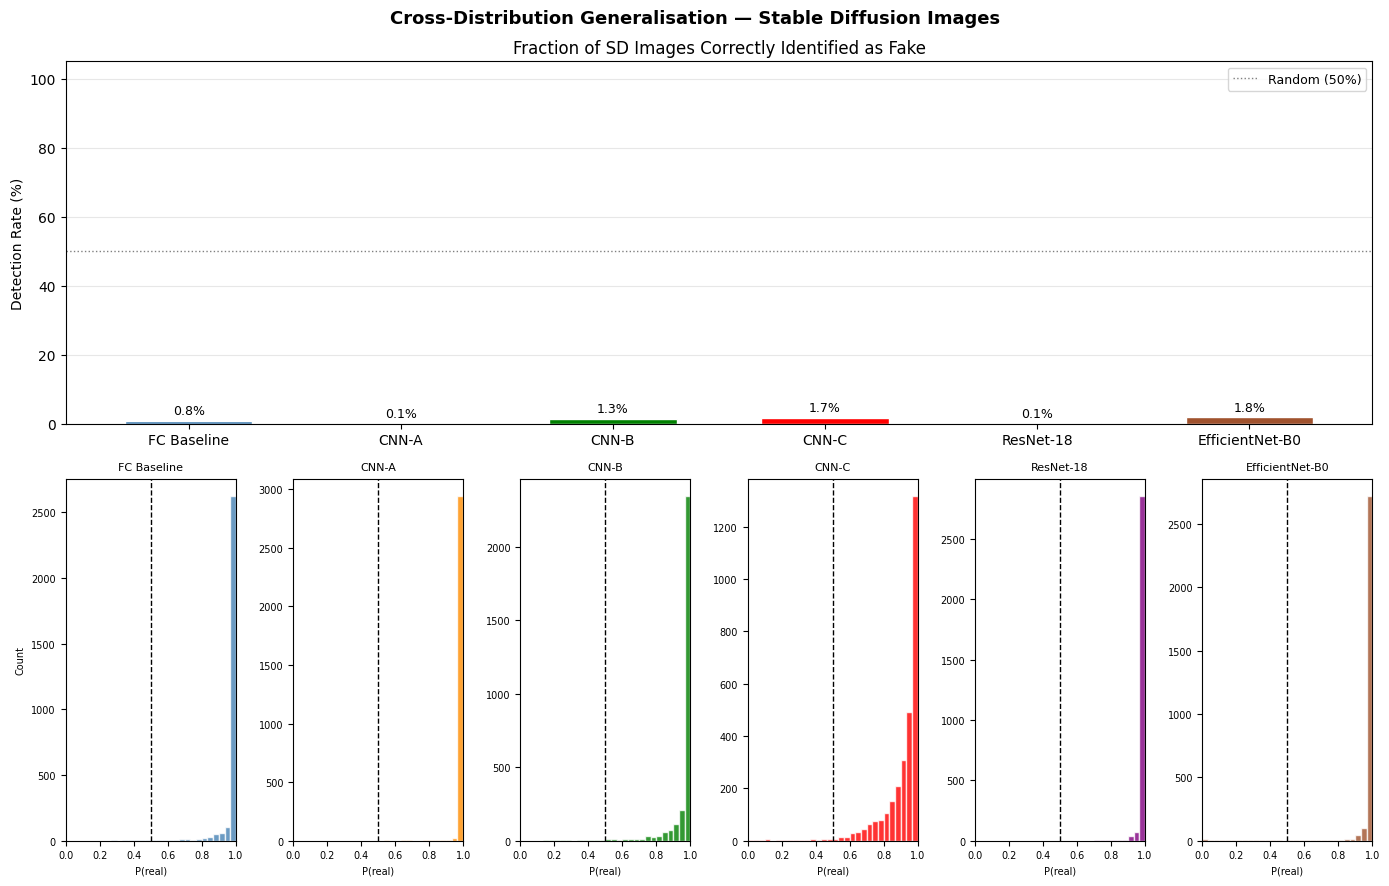

In [51]:
#Plots
names      = list(cross_results.keys())
det_rates  = [cross_results[n]['detection_rate'] * 100 for n in names]
colors     = ['steelblue', 'darkorange', 'green', 'red', 'purple', 'sienna']

fig = plt.figure(figsize=(14, 9))
fig.suptitle('Cross-Distribution Generalisation — Stable Diffusion Images',
             fontweight='bold', fontsize=13)

#Bar chart
ax_bar = fig.add_subplot(2, 1, 1)
bars = ax_bar.bar(names, det_rates, color=colors, edgecolor='white', width=0.6)
ax_bar.axhline(50, color='grey', ls=':', lw=1, label='Random (50%)')
ax_bar.set_ylim(0, 105)
ax_bar.set_ylabel('Detection Rate (%)')
ax_bar.set_title('Fraction of SD Images Correctly Identified as Fake')
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='y', alpha=0.3)
for bar, rate in zip(bars, det_rates):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)

#Probability histograms
for i, (name, color) in enumerate(zip(names, colors)):
    ax = fig.add_subplot(2, 6, 7 + i)
    ax.hist(cross_results[name]['y_prob'], bins=30, range=(0, 1),
            color=color, alpha=0.8, edgecolor='white')
    ax.axvline(0.5, color='black', ls='--', lw=1)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel('P(real)', fontsize=7)
    ax.set_xlim(0, 1)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.set_ylabel('Count', fontsize=7)

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR_S3 / 'cross_dataset_sd_results.png', dpi=150, bbox_inches='tight')
plt.show()